In [10]:
import importlib
import aaro_draft
import pandas as pd
import matplotlib.pyplot as plt
import Conor
from IPython.display import Image, display
from joblib import Parallel, delayed

importlib.reload(aaro_draft)
importlib.reload(Conor)

<module 'Conor' from '/workspaces/Research-Skills-for-Financial-Mathematics/Conor.py'>

In [11]:
import aaro_draft as ad
import Conor as c

In [12]:
cfg = c.ExpConfig(
    alpha=0.5,
    label="alpha=0.5"
)
results = c.run_experiment([cfg], n_jobs=-1)



--- Running: alpha=0.5 ---
    Done. Final mean VPI: -0.774


In [13]:
results["alpha=0.5"]["vpi"][:10]

array([-170.50030391,  -22.66749117,  -45.46008767,  -22.24638686,
        -49.0339289 ,  -43.12119469,  -17.52807032,  -11.57072382,
        -13.44800754,  -14.8795601 ])

### Why very large values of $\alpha$ (e.g., 100 or 500) do not work well

In the algorithm, the exploration bonus in the UCB update is

$$
\text{UCB} = \frac{\text{scaling}}{n^\alpha} + \text{scaling}\cdot \text{radius},
$$

where $n$ is the number of visits to the active node.

When $\alpha$ is extremely large (e.g., 100 or 500), the term $n^{-\alpha}$ decays **extremely quickly**.

For example:

- $1 / 2^{100} \approx 7.9 \times 10^{-31}$
- $1 / 3^{100} \approx 5.2 \times 10^{-48}$

After only one or two visits, the exploration bonus from the $n^{-\alpha}$ term becomes essentially **zero**.

As a result:

- The algorithm stops encouraging exploration very early.
- The Q-value updates become almost purely greedy.
- The agent may commit prematurely to suboptimal regions of the state–action space.
- The adaptive partitioning receives poor information, which can degrade learning performance.

Although the radius term still provides some spatial optimism, the rapid collapse of $n^{-\alpha}$ makes the algorithm behave much less like a UCB-style method.

For this reason, extremely large values such as $\alpha = 100$ or $\alpha = 500$ are not very informative in practice. More meaningful comparisons usually occur for values such as

$$
\alpha \in [0.01, 1],
$$

where the exploration bonus decays at a reasonable rate.


--- Running: alpha=0.01 ---


    Done. Final mean VPI: -0.719

--- Running: alpha=0.05 ---
    Done. Final mean VPI: -0.878

--- Running: alpha=0.1 ---
    Done. Final mean VPI: -1.005

--- Running: alpha=0.5 ---
    Done. Final mean VPI: -0.751

--- Running: alpha=1 ---
    Done. Final mean VPI: -0.753

--- Running: alpha=5 ---
    Done. Final mean VPI: -0.740

--- Running: alpha=10 ---
    Done. Final mean VPI: -0.781

--- Running: alpha=50 ---
    Done. Final mean VPI: -0.752


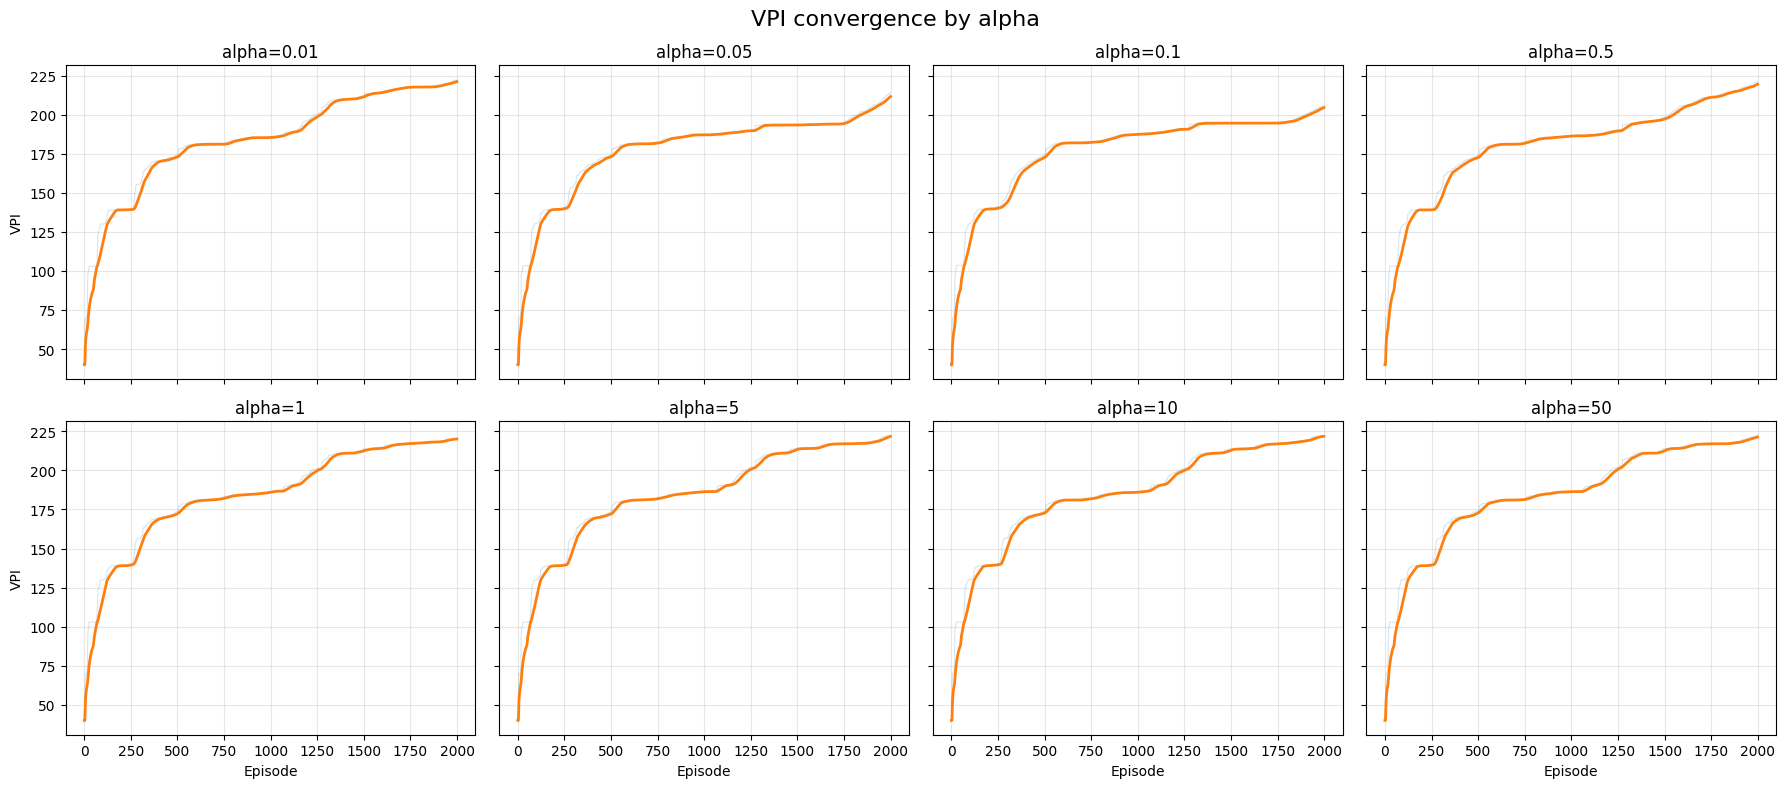

In [14]:
import numpy as np
import matplotlib.pyplot as plt
#alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]


alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

configs = [
    c.ExpConfig(alpha=a, label=f"alpha={a}")
    for a in alphas
]

results = c.run_experiment(configs, n_jobs=-1)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()

smooth_window = 50

for ax, a in zip(axes, alphas):
    label = f"alpha={a}"
    arms = np.asarray(results[label]["arms"], dtype=float)
    episodes = np.arange(len(arms))

    cumsum = np.cumsum(np.insert(arms, 0, 0.0))
    smoothed = np.empty_like(arms)
    for i in range(len(arms)):
        start = max(0, i - smooth_window + 1)
        smoothed[i] = (cumsum[i + 1] - cumsum[start]) / (i - start + 1)

    ax.plot(episodes, arms, alpha=0.18, linewidth=0.8)
    ax.plot(episodes, smoothed, linewidth=2)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes):
    if i >= 4:
        ax.set_xlabel("Episode")
    if i % 4 == 0:
        ax.set_ylabel("VPI")

fig.suptitle("VPI convergence by alpha", fontsize=16)
fig.tight_layout()
plt.show()

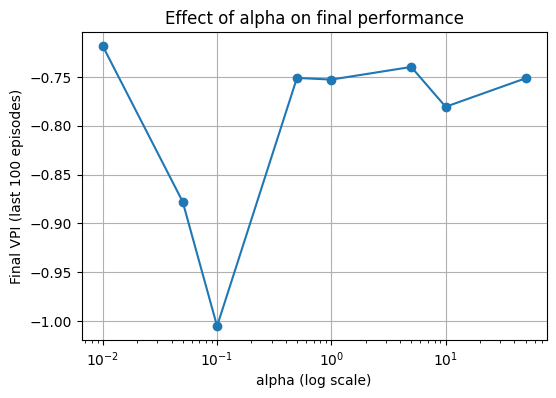

In [15]:


final_vpi = []

for a in alphas:
    label = f"alpha={a}"
    v = np.asarray(results[label]["vpi"], dtype=float)
    final_vpi.append(np.mean(v[-100:]))

plt.figure(figsize=(6,4))
plt.plot(alphas, final_vpi, marker='o')
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Final VPI (last 100 episodes)")
plt.title("Effect of alpha on final performance")
plt.grid(True)
plt.show()


--- Running: alpha=0.01 ---
    Done. Final mean VPI: -0.718

--- Running: alpha=0.05 ---
    Done. Final mean VPI: -0.909

--- Running: alpha=0.1 ---
    Done. Final mean VPI: -0.976

--- Running: alpha=0.5 ---
    Done. Final mean VPI: -0.720

--- Running: alpha=1 ---
    Done. Final mean VPI: -0.789

--- Running: alpha=5 ---
    Done. Final mean VPI: -0.783

--- Running: alpha=10 ---
    Done. Final mean VPI: -0.710

--- Running: alpha=50 ---
    Done. Final mean VPI: -0.709


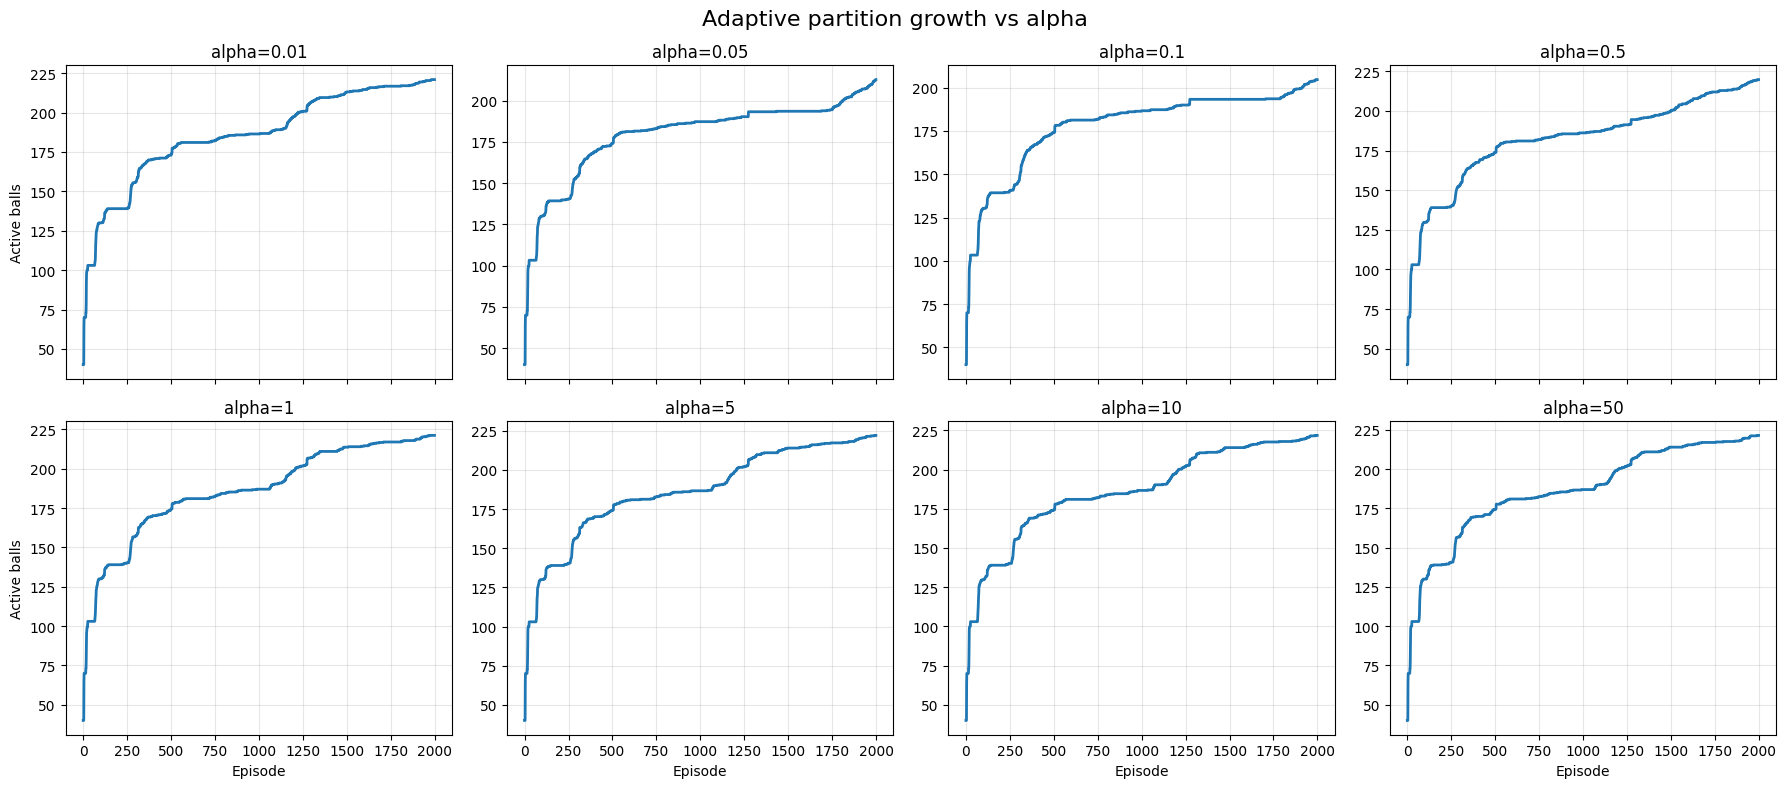

In [16]:
alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

configs = [
    c.ExpConfig(alpha=a, label=f"alpha={a}")
    for a in alphas
]

results = c.run_experiment(configs, n_jobs=-1)


fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.ravel()

for ax, a in zip(axes, alphas):
    label = f"alpha={a}"
    arms = results[label]["arms"]

    ax.plot(arms, linewidth=2)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes):
    if i >= 4:
        ax.set_xlabel("Episode")
    if i % 4 == 0:
        ax.set_ylabel("Active balls")

fig.suptitle("Adaptive partition growth vs alpha", fontsize=16)
fig.tight_layout()
plt.show()

The above plot explains how quick the partition grows. We seee rapid growth early on and then a plateua arond 200 ish. Overall the algorithim doesnt seem to be vey sensitive to alpha as there is little difference between alpha = 0.1 and alpha = 50

Starting 10 parallel experiments...


**************************************************
Running experiment
**************************************************
**************************************************
Running experiment
**************************************************
**************************************************
Experiment complete
**************************************************
**************************************************
Saving data
**************************************************
**************************************************
Running experiment
**************************************************
**************************************************
Experiment complete
**************************************************
**************************************************
Saving data
**************************************************
**************************************************
Running experiment
**************************************************
********************************************

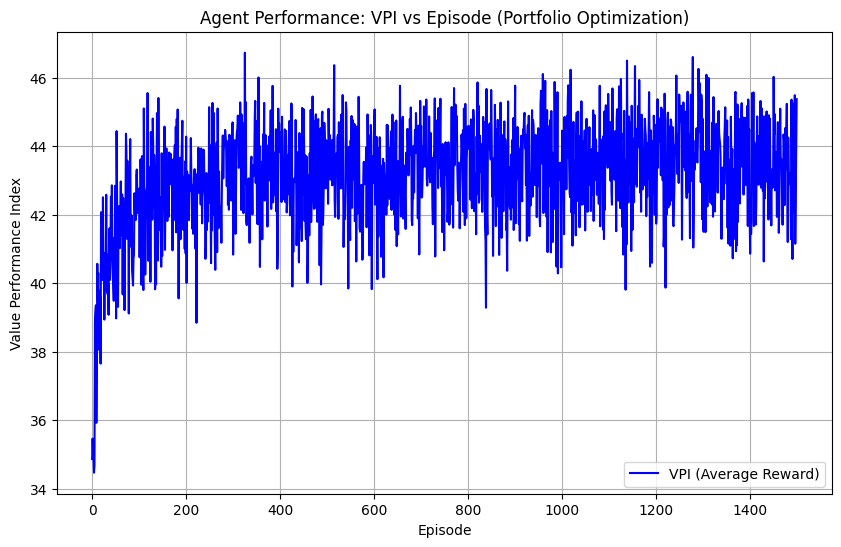

Final Average Reward after 1500 episodes: 45.3773


In [17]:
n_simulations = 10 

print(f"Starting {n_simulations} parallel experiments...")

# Run the parallel experiment loop using the function from your imported module
# This triggers run_single_experiment_iteration(i) for i in range(0, 50)
list_of_results = Parallel(n_jobs=-1)(
    delayed(ad.run_single_experiment_iteration)(i) for i in range(n_simulations)
)

# Process the results into a mean estimate (VPI)
vpi_df = pd.DataFrame(list_of_results).T
vpi_estimate = vpi_df.mean(axis=1)

# Generate the plot
plt.figure(figsize=(10, 6))
plt.plot(range(len(vpi_estimate)), vpi_estimate, label='VPI (Average Reward)', color='blue')
plt.xlabel("Episode")
plt.ylabel("Value Performance Index")
plt.title("Agent Performance: VPI vs Episode (Portfolio Optimization)")
plt.legend()
plt.grid(True)
plt.show()

# final average reward achieved
print(f"Final Average Reward after {ad.nEps} episodes: {vpi_estimate.iloc[-1]:.4f}")

In [18]:

cfgs = [
    c.ExpConfig(alpha=0.5, starting_state=s0, rho=30.0, label=f"start={s0}|alpha=0.5")
    for s0 in [-20, -10, 0, 4, 10, 20]
]

res = c.run_experiment(cfgs, n_jobs=1)
print(res.keys())


--- Running: start=-20|alpha=0.5 ---


    Done. Final mean VPI: -944.001

--- Running: start=-10|alpha=0.5 ---
    Done. Final mean VPI: -160.672

--- Running: start=0|alpha=0.5 ---
    Done. Final mean VPI: -20.073

--- Running: start=4|alpha=0.5 ---
    Done. Final mean VPI: -0.671

--- Running: start=10|alpha=0.5 ---
    Done. Final mean VPI: -72.923

--- Running: start=20|alpha=0.5 ---
    Done. Final mean VPI: -855.073
dict_keys(['start=-20|alpha=0.5', 'start=-10|alpha=0.5', 'start=0|alpha=0.5', 'start=4|alpha=0.5', 'start=10|alpha=0.5', 'start=20|alpha=0.5'])


### Experiment to vary over multiple alphas and multiple $x_0$. 


--- Running: start=-3|alpha=0.1 ---
    Done. Final mean VPI: -74.358

--- Running: start=-3|alpha=0.5 ---
    Done. Final mean VPI: -74.236

--- Running: start=-3|alpha=5.0 ---
    Done. Final mean VPI: -74.465

--- Running: start=0|alpha=0.1 ---
    Done. Final mean VPI: -21.779

--- Running: start=0|alpha=0.5 ---
    Done. Final mean VPI: -20.073

--- Running: start=0|alpha=5.0 ---
    Done. Final mean VPI: -21.856

--- Running: start=2|alpha=0.1 ---
    Done. Final mean VPI: -7.047

--- Running: start=2|alpha=0.5 ---
    Done. Final mean VPI: -6.392

--- Running: start=2|alpha=5.0 ---
    Done. Final mean VPI: -4.367

--- Running: start=4|alpha=0.1 ---
    Done. Final mean VPI: -0.810

--- Running: start=4|alpha=0.5 ---
    Done. Final mean VPI: -0.671

--- Running: start=4|alpha=5.0 ---
    Done. Final mean VPI: -0.709

--- Running: start=7|alpha=0.1 ---
    Done. Final mean VPI: -9.866

--- Running: start=7|alpha=0.5 ---
    Done. Final mean VPI: -9.709

--- Running: start=7|alp

,starting_state,alpha,final_vpi_100,final_arms_100,mean_vpi_all,max_arms
0,-3,0.1,-74.357768,201.700,-80.195522,201.7
1,-3,0.5,-74.235956,202.000,-80.034896,202.0
2,-3,5.0,-74.464925,201.700,-80.084279,201.7
3,0,0.1,-21.778639,289.930,-23.561333,292.3
4,0,0.5,-20.073281,292.780,-21.900625,293.8
5,0,5.0,-21.856135,292.633,-23.654474,293.2
6,2,0.1,-7.046763,194.422,-7.997887,195.1
7,2,0.5,-6.392028,198.541,-7.376029,199.0
8,2,5.0,-4.366705,199.264,-5.790155,199.6
9,4,0.1,-0.810146,196.306,-1.622818,196.9


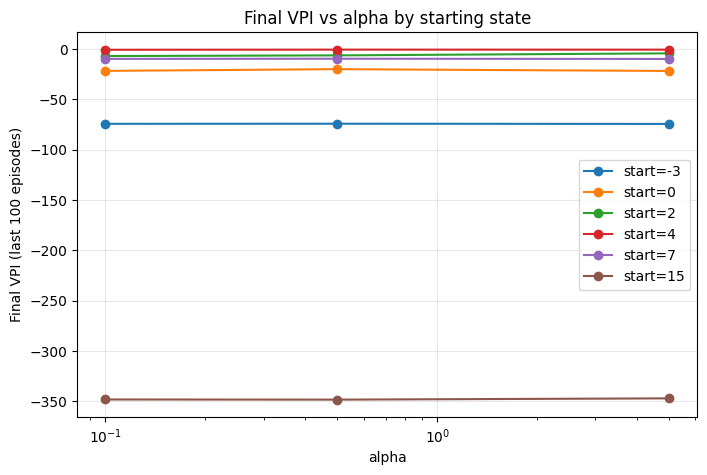

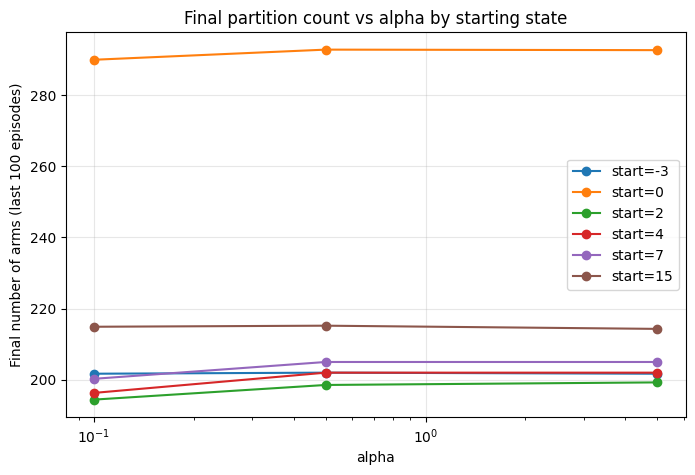

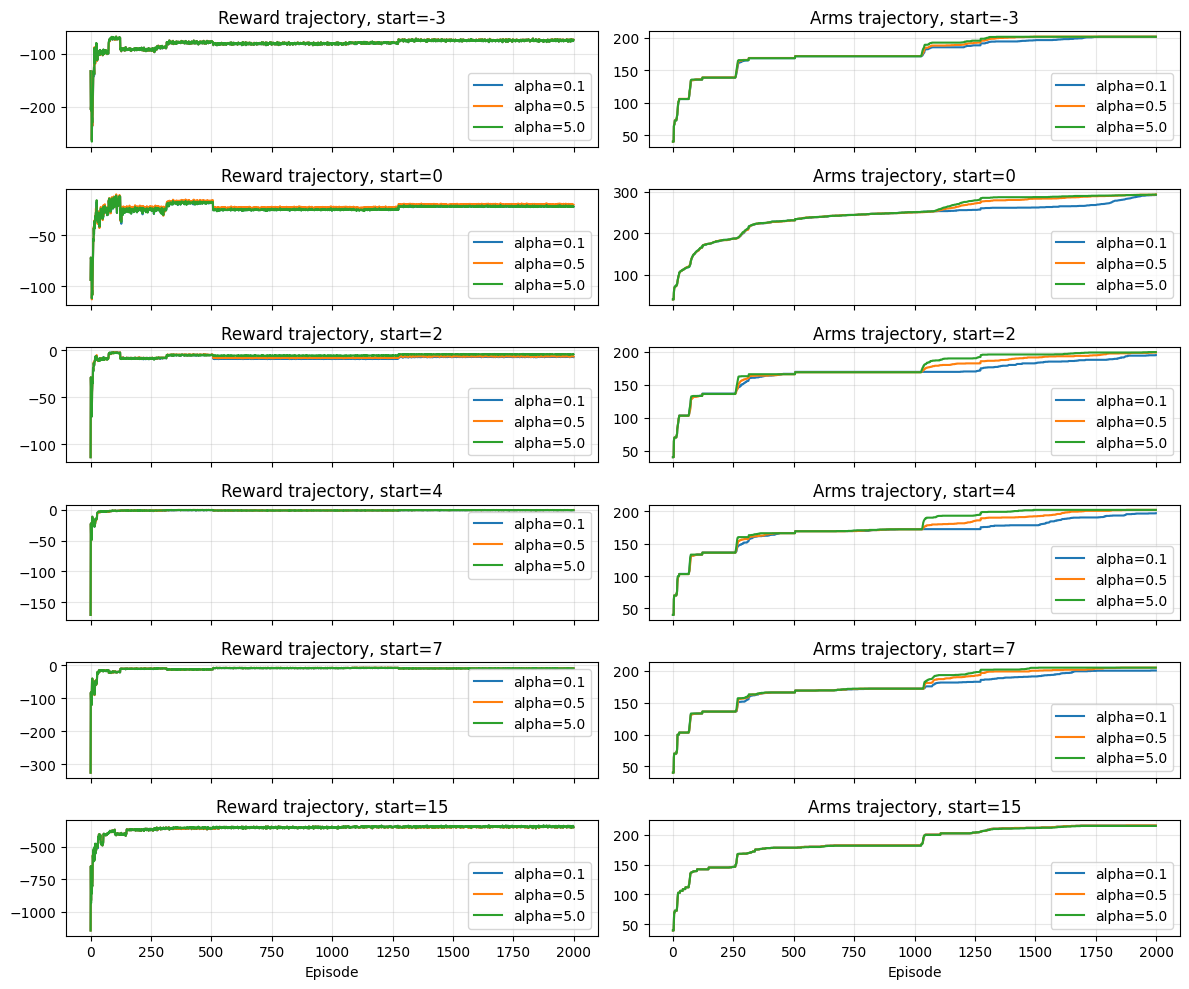

,starting_state,alpha,final_vpi_100,final_arms_100
1,-3,0.5,-74.235956,202.000
4,0,0.5,-20.073281,292.780
8,2,5.0,-4.366705,199.264
10,4,0.5,-0.670514,202.000
13,7,0.5,-9.708717,205.000
17,15,5.0,-346.952784,214.300


In [19]:


# -----------------------------
# Experiment settings
# -----------------------------
starting_states = [-3, 0, 2, 4, 7, 15]
alphas = [0.1, 0.5, 5.0]
rho_val = 30.0

# -----------------------------
# Run sweep
# -----------------------------
all_results = {}

for s0 in starting_states:
    configs = [
        c.ExpConfig(
            alpha=a,
            starting_state=s0,
            rho=rho_val,
            label=f"start={s0}|alpha={a}"
        )
        for a in alphas
    ]
    all_results[s0] = c.run_experiment(configs, n_jobs=1)

# -----------------------------
# Build summary table
# -----------------------------
rows = []

for s0 in starting_states:
    for a in alphas:
        label = f"start={s0}|alpha={a}"
        vpi = np.asarray(all_results[s0][label]["vpi"], dtype=float)
        arms = np.asarray(all_results[s0][label]["arms"], dtype=float)

        rows.append({
            "starting_state": s0,
            "alpha": a,
            "final_vpi_100": vpi[-100:].mean(),
            "final_arms_100": arms[-100:].mean(),
            "mean_vpi_all": vpi.mean(),
            "max_arms": arms.max()
        })

summary_df = pd.DataFrame(rows).sort_values(["starting_state", "alpha"])
display(summary_df)

# -----------------------------
# Plot 1: Final VPI vs alpha
# -----------------------------
plt.figure(figsize=(8, 5))

for s0 in starting_states:
    sub = summary_df[summary_df["starting_state"] == s0]
    plt.plot(sub["alpha"], sub["final_vpi_100"], marker="o", label=f"start={s0}")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Final VPI (last 100 episodes)")
plt.title("Final VPI vs alpha by starting state")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# Plot 2: Final arms vs alpha
# -----------------------------
plt.figure(figsize=(8, 5))

for s0 in starting_states:
    sub = summary_df[summary_df["starting_state"] == s0]
    plt.plot(sub["alpha"], sub["final_arms_100"], marker="o", label=f"start={s0}")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Final number of arms (last 100 episodes)")
plt.title("Final partition count vs alpha by starting state")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# Plot 3: Reward trajectories
# -----------------------------
starts_to_show = [-3, 0, 2, 4, 7, 15]

fig, axes = plt.subplots(len(starts_to_show), 2, figsize=(12, 10), sharex=True)

for i, s0 in enumerate(starts_to_show):
    for a in alphas:
        label = f"start={s0}|alpha={a}"
        vpi = np.asarray(all_results[s0][label]["vpi"], dtype=float)
        arms = np.asarray(all_results[s0][label]["arms"], dtype=float)

        axes[i, 0].plot(vpi, label=f"alpha={a}")
        axes[i, 1].plot(arms, label=f"alpha={a}")

    axes[i, 0].set_title(f"Reward trajectory, start={s0}")
    axes[i, 1].set_title(f"Arms trajectory, start={s0}")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 0].legend()
    axes[i, 1].legend()

axes[-1, 0].set_xlabel("Episode")
axes[-1, 1].set_xlabel("Episode")
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: best alpha by start
# -----------------------------
best_by_start = summary_df.loc[
    summary_df.groupby("starting_state")["final_vpi_100"].idxmax()
][["starting_state", "alpha", "final_vpi_100", "final_arms_100"]]

display(best_by_start)

The benchmark is highly sensitive to the initial state. Performance improves substantially when the process starts near the feasible action region, while negative initial states perform much worse. Although the exploration decay parameter $ \alpha $ interacts with the part of the state space explored early on, the best-performing values remain in a fairly narrow range and the performance differences between them are modest.

The partition counts are also revealing. Aside from the start at 0 (This set up encourages the learning both positive and negative actions when starting at 0 ), which produced noticeably more arms, the number of active partitions stays in a tight band of roughly 205–213 across starting states. This means the sharp decline in performance for negative starts is not being driven by a failure to refine the partition. Instead, it points to a structural difficulty in the control problem itself: the action space is bounded to a feasible region that aligns much better with positive states than with negative ones.

So the main takeaways are:
- Performance improves dramatically when the initial state lies near the feasible action region.
- Different α values can be preferred in different parts of the state space, but the differences are small enough to suggest moderate robustness.
- Large swings in performance are not matched by similarly large swings in partition growth, which suggests adaptive discretization is not the main bottleneck in this toy problem

These observations are specific to the quadratic reward and bounded action space used in the benchmark, but they illustrate how adaptive partition methods may behave differently depending on the region of the state space explored early in learning

## Experimental Setup

We consider the one–dimensional linear diffusion control problem described in Section 6.1.  
The environment dynamics are given by

$$
X_{t+1} = X_t + (\theta_0 + \theta_x X_t + \theta_a a_t)\Delta + \sigma\sqrt{\Delta}\,Z_t,
$$

where $Z_t \sim \mathcal{N}(0,1)$ represents Gaussian noise.

### Reward Function

The reward at each step is defined as

$$
r(x,a) = -(x-a)^2 + \varepsilon,
$$

where

$$
\varepsilon \sim \mathcal{N}(0,0.01).
$$

This quadratic loss encourages the action to match the state, with the optimal action satisfying

$$
a^* = x
$$

in the absence of action constraints.

### Action Space

Actions are restricted to the feasible region

$$
a \in [0,10].
$$

This constraint means the agent cannot perfectly match the optimal action when the state lies outside this interval.

### State Domain

The state is projected onto a bounded domain

$$
x \in [-50,50].
$$

The adaptive partition tree is initialized with localization radius

$$
\rho = 30.
$$

### Key Hyperparameters

| Parameter | Value |
|----------|------|
| Episode length | $H = 10$ |
| Episodes | $K = 2000$ |
| Seeds | $10$ |
| Noise level | $\sigma = 0.1$ |
| Scaling parameter | $c = 5$ |
| Split threshold | $2$ |

### Exploration Decay

The confidence bonus used in the algorithm is

$$
\text{UCB}(B) = \frac{c}{n(B)^\alpha} + c \cdot \text{rad}(B),
$$

where $n(B)$ is the number of visits to partition $B$ and $\alpha$ controls the rate at which exploration decays.

### Initial States Tested

The experiments evaluate sensitivity to initialization using

$$
x_0 \in \{-3, 0, 2, 4, 7, 15\}.
$$

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Conor as c
import importlib
importlib.reload(c)

starting_states = [-3, 0, 2, 4, 7, 15]
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
alpha_fixed = 0.5
rho_val = 30.0

all_results_c = {}
for s0 in starting_states:
    configs = [
        c.ExpConfig(
            alpha=alpha_fixed,
            scaling=sc,
            starting_state=s0,
            rho=rho_val,
            action_lo=-5.0,
            action_hi=5.0,
            initial_q=100.0,
            reward_step_fn=c.reward_quadratic_asymmetric,
            label=f"start={s0}|c={sc}"
        )
        for sc in scalings
    ]
    all_results_c[s0] = c.run_experiment(configs, n_jobs=1)


--- Running: start=-3|c=0.01 ---


    Done. Final mean VPI: -26.533

--- Running: start=-3|c=0.05 ---
    Done. Final mean VPI: -26.955

--- Running: start=-3|c=0.1 ---
    Done. Final mean VPI: -26.508

--- Running: start=-3|c=0.5 ---
    Done. Final mean VPI: -20.587

--- Running: start=-3|c=1 ---
    Done. Final mean VPI: -15.732

--- Running: start=-3|c=5 ---
    Done. Final mean VPI: -47.950

--- Running: start=-3|c=10 ---
    Done. Final mean VPI: -299.642

--- Running: start=-3|c=50 ---
    Done. Final mean VPI: -970.242

--- Running: start=0|c=0.01 ---
    Done. Final mean VPI: -32.231

--- Running: start=0|c=0.05 ---
    Done. Final mean VPI: -28.980

--- Running: start=0|c=0.1 ---
    Done. Final mean VPI: -28.159

--- Running: start=0|c=0.5 ---
    Done. Final mean VPI: -18.083

--- Running: start=0|c=1 ---
    Done. Final mean VPI: -12.407

--- Running: start=0|c=5 ---
    Done. Final mean VPI: -57.923

--- Running: start=0|c=10 ---
    Done. Final mean VPI: -123.194

--- Running: start=0|c=50 ---
    Done.

In [21]:
rows = []

for s0 in starting_states:
    for sc in scalings:
        label = f"start={s0}|c={sc}"
        vpi = np.asarray(all_results_c[s0][label]["vpi"], dtype=float)
        arms = np.asarray(all_results_c[s0][label]["arms"], dtype=float)

        rows.append({
            "starting_state": s0,
            "scaling": sc,
            "final_vpi_100": vpi[-100:].mean(),
            "final_arms_100": arms[-100:].mean(),
            "mean_vpi_all": vpi.mean(),
            "max_arms": arms.max()
        })

summary_c_df = pd.DataFrame(rows).sort_values(["starting_state", "scaling"])
display(summary_c_df)

,starting_state,scaling,final_vpi_100,final_arms_100,mean_vpi_all,max_arms
0,-3,0.01,-26.533494,198.430,-25.757953,199.0
1,-3,0.05,-26.954594,198.364,-26.011737,198.7
2,-3,0.10,-26.508416,198.820,-25.825232,199.3
3,-3,0.50,-20.587019,201.583,-20.751384,202.3
4,-3,1.00,-15.731795,204.616,-17.908085,205.0
5,-3,5.00,-47.949806,201.706,-56.446451,202.0
6,-3,10.00,-299.642418,199.300,-318.155495,199.3
7,-3,50.00,-970.242158,198.400,-989.216843,198.4
8,0,0.01,-32.230997,302.872,-31.842628,303.1
9,0,0.05,-28.979762,303.748,-28.731744,304.0


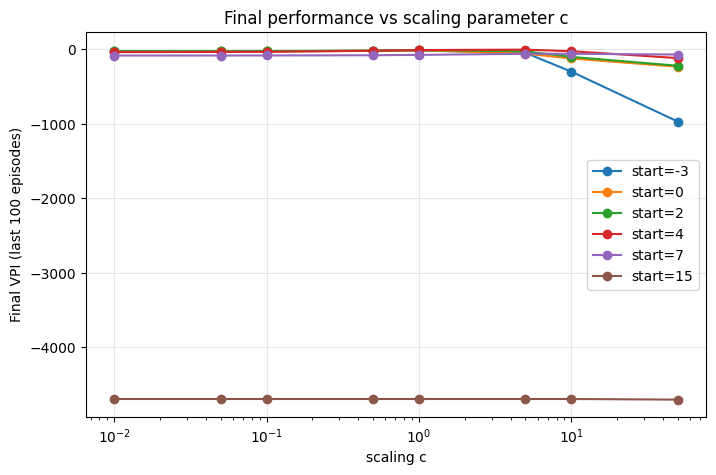

In [22]:
plt.figure(figsize=(8,5))

for s0 in starting_states:
    sub = summary_c_df[summary_c_df["starting_state"] == s0]
    plt.plot(sub["scaling"], sub["final_vpi_100"], marker="o", label=f"start={s0}")

plt.xscale("log")
plt.xlabel("scaling c")
plt.ylabel("Final VPI (last 100 episodes)")
plt.title("Final performance vs scaling parameter c")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

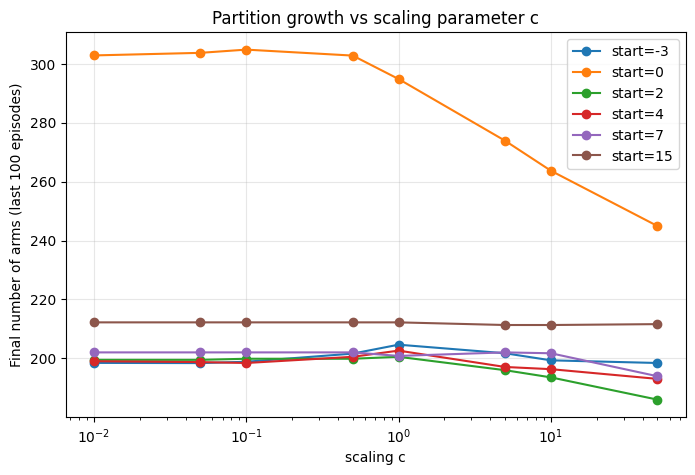

In [23]:
plt.figure(figsize=(8,5))

for s0 in starting_states:
    sub = summary_c_df[summary_c_df["starting_state"] == s0]
    plt.plot(sub["scaling"], sub["final_arms_100"], marker="o", label=f"start={s0}")

plt.xscale("log")
plt.xlabel("scaling c")
plt.ylabel("Final number of arms (last 100 episodes)")
plt.title("Partition growth vs scaling parameter c")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

partition growth is indifferent to scaling parameters

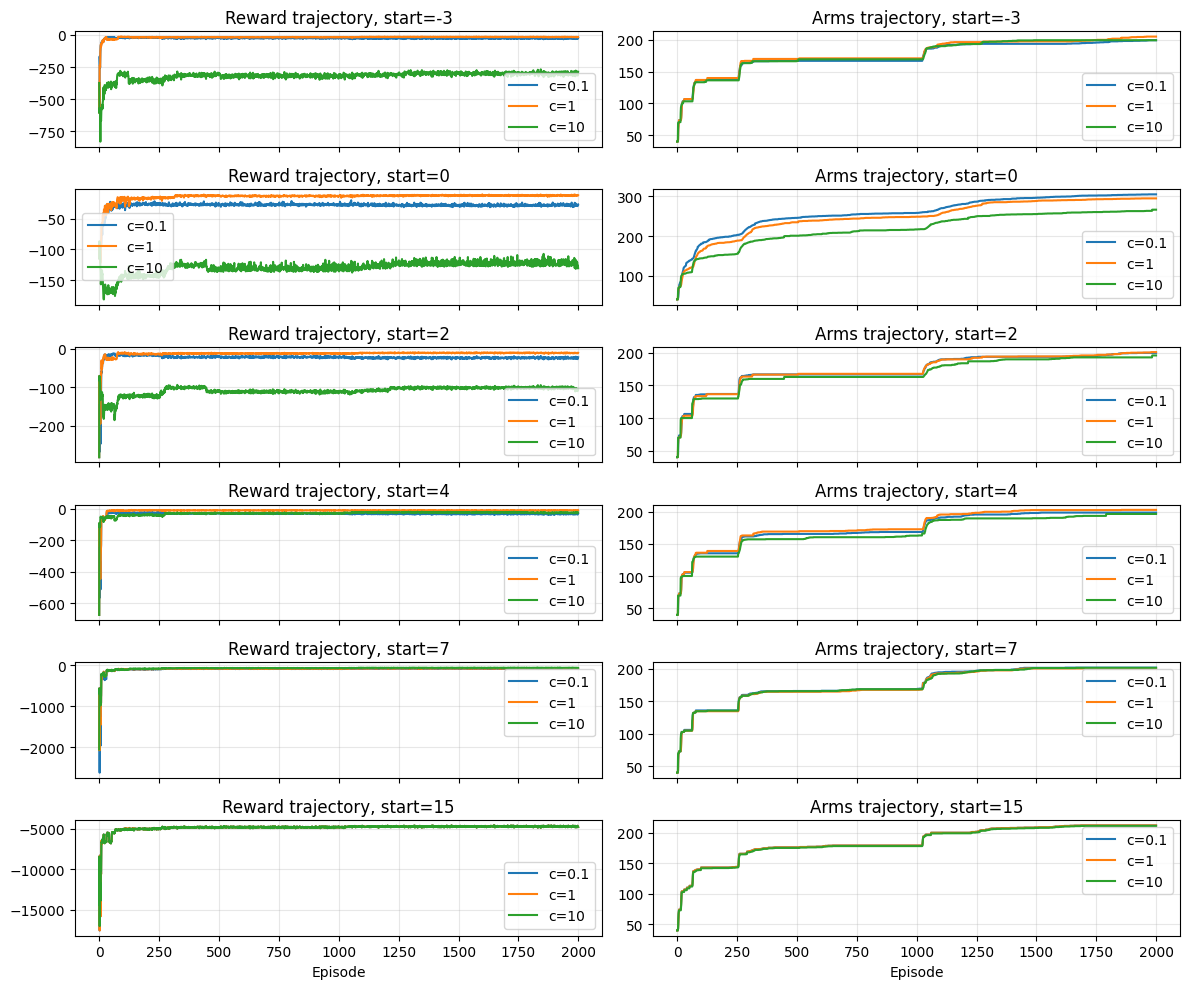

In [24]:
scalings_to_show = [0.1, 1, 10]

fig, axes = plt.subplots(len(starting_states), 2, figsize=(12, 10), sharex=True)

for i, s0 in enumerate(starting_states):
    for sc in scalings_to_show:
        label = f"start={s0}|c={sc}"
        vpi = np.asarray(all_results_c[s0][label]["vpi"], dtype=float)
        arms = np.asarray(all_results_c[s0][label]["arms"], dtype=float)

        axes[i, 0].plot(vpi, label=f"c={sc}")
        axes[i, 1].plot(arms, label=f"c={sc}")

    axes[i, 0].set_title(f"Reward trajectory, start={s0}")
    axes[i, 1].set_title(f"Arms trajectory, start={s0}")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 0].legend()
    axes[i, 1].legend()

axes[-1, 0].set_xlabel("Episode")
axes[-1, 1].set_xlabel("Episode")
plt.tight_layout()
plt.show()

In [25]:
best_scaling_by_start = summary_c_df.loc[
    summary_c_df.groupby("starting_state")["final_vpi_100"].idxmax()
][["starting_state", "scaling", "final_vpi_100", "final_arms_100"]]

print(best_scaling_by_start)

    starting_state  scaling  final_vpi_100  final_arms_100
4               -3     1.00     -15.731795         204.616
12               0     1.00     -12.406664         294.859
20               2     1.00     -11.299934         200.497
29               4     5.00      -4.397717         197.047
38               7    10.00     -60.195729         201.700
40              15     0.01   -4691.653194         212.200


The most optimal scaling parameter $c \in \{0.5, 1\}$ we see also that as we start further away from the optimal value we prefer to have a large scaling parameter. This is because when the initial state is already close to the optimal region (e.g. $x_0 \in [2,4]$), the algorithm benefits from **less exploration** ($c \approx 0.5$), whereas for more difficult starting states further from the optimal region the algorithm benefits from **greater optimism in the exploration bonus** ($c \approx 1$). 

The number of arms staying in a rough same interval suggest The scaling parameter mainly affects exploration optimism rather than dramatically changing the total number of partitions with the exception of 0 again for the same reason.




The scaling parameter $c$ controls the magnitude of the exploration bonus in the UCB term. In the update rule the bonus appears as

$$
\text{UCB bonus} = \frac{c}{n(B)^{\alpha}} + c \cdot \text{radius}(B),
$$

where $n(B)$ is the number of visits to region $B$ and $\text{radius}(B)$ is the size of the partition cell.

Increasing $c$ increases the exploration bonus, which makes the $Q$-value estimates more **optimistic** for rarely visited regions. This encourages the algorithm to **explore more** by selecting actions in less-sampled parts of the state–action space.

Conversely, decreasing $c$ reduces the exploration bonus, making the value estimates less optimistic and causing the algorithm to rely more on observed rewards, which leads to **less exploration and more exploitation** of regions that already appear promising.

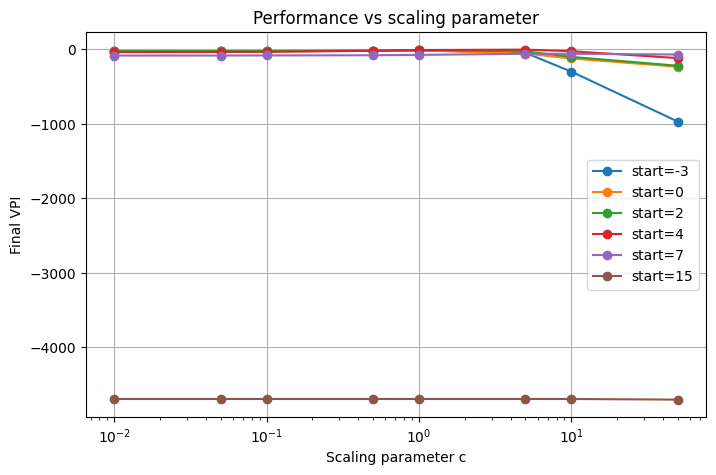

In [26]:
plt.figure(figsize=(8,5))

for s0 in summary_c_df["starting_state"].unique():
    sub = summary_c_df[summary_c_df["starting_state"] == s0]
    plt.plot(sub["scaling"], sub["final_vpi_100"], marker="o", label=f"start={s0}")

plt.xscale("log")
plt.xlabel("Scaling parameter c")
plt.ylabel("Final VPI")
plt.title("Performance vs scaling parameter")
plt.grid(True)
plt.legend()
plt.show()

This plot is quite informative, it shows that for c values large than 1 our performace drops off significantly for most of the starting states. C effects mostly when our starting state is not in our action space. for large values of c 10, 50 the algorithim gets overly optimistic and repeated explores poor regions this dramatically slows the learning 

# New experiment with proper action bounds

In [27]:
import importlib
import Conor as c
importlib.reload(c)


starting_states_asym = [0, 2, 4]
scalings = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
alpha_fixed = 0.5
rho_val = 30.0

all_results_asym = {}

for s0 in starting_states_asym:
    configs = [
        c.ExpConfig(
            alpha=alpha_fixed,
            scaling=sc,
            starting_state=s0,
            rho=rho_val,
            action_lo=-5.0,
            action_hi=5.0,
            initial_q=100.0,
            reward_step_fn=c.reward_quadratic_asymmetric,
            label=f"start={s0}|c={sc}"
        )
        for sc in scalings
    ]
    all_results_asym[s0] = c.run_experiment(configs, n_jobs=1)


--- Running: start=0|c=0.01 ---
    Done. Final mean VPI: -32.231

--- Running: start=0|c=0.05 ---
    Done. Final mean VPI: -28.980

--- Running: start=0|c=0.1 ---
    Done. Final mean VPI: -28.159

--- Running: start=0|c=0.5 ---
    Done. Final mean VPI: -18.083

--- Running: start=0|c=1 ---
    Done. Final mean VPI: -12.407

--- Running: start=0|c=5 ---
    Done. Final mean VPI: -57.923

--- Running: start=0|c=10 ---
    Done. Final mean VPI: -123.194

--- Running: start=0|c=50 ---
    Done. Final mean VPI: -234.063

--- Running: start=2|c=0.01 ---
    Done. Final mean VPI: -26.234

--- Running: start=2|c=0.05 ---
    Done. Final mean VPI: -26.018

--- Running: start=2|c=0.1 ---
    Done. Final mean VPI: -24.022

--- Running: start=2|c=0.5 ---
    Done. Final mean VPI: -17.156

--- Running: start=2|c=1 ---
    Done. Final mean VPI: -11.300

--- Running: start=2|c=5 ---
    Done. Final mean VPI: -26.640

--- Running: start=2|c=10 ---
    Done. Final mean VPI: -101.993

--- Running: 

In [28]:
import numpy as np
rows = []
for s0 in starting_states_asym:
    for sc in scalings:
        label = f"start={s0}|c={sc}"
        vpi = np.asarray(all_results_asym[s0][label]["vpi"], dtype=float)
        arms = np.asarray(all_results_asym[s0][label]["arms"], dtype=float)
        rows.append({
            "starting_state": s0,
            "scaling": sc,
            "final_vpi_100": vpi[-100:].mean(),
            "final_arms_100": arms[-100:].mean(),
            "mean_vpi_all": vpi.mean(),
            "max_arms": arms.max()
        })

summary_asym_df = pd.DataFrame(rows).sort_values(["starting_state", "scaling"])
display(summary_asym_df)

,starting_state,scaling,final_vpi_100,final_arms_100,mean_vpi_all,max_arms
0,0,0.01,-32.230997,302.872,-31.842628,303.1
1,0,0.05,-28.979762,303.748,-28.731744,304.0
2,0,0.10,-28.159244,304.843,-28.556766,305.2
3,0,0.50,-18.083222,302.818,-18.815841,303.1
4,0,1.00,-12.406664,294.859,-14.569654,295.0
5,0,5.00,-57.922559,273.889,-62.599756,274.6
6,0,10.00,-123.193802,263.689,-129.287668,266.5
7,0,50.00,-234.063249,244.918,-239.827119,245.8
8,2,0.01,-26.233577,199.468,-24.877842,199.6
9,2,0.05,-26.017510,199.468,-24.602910,199.6


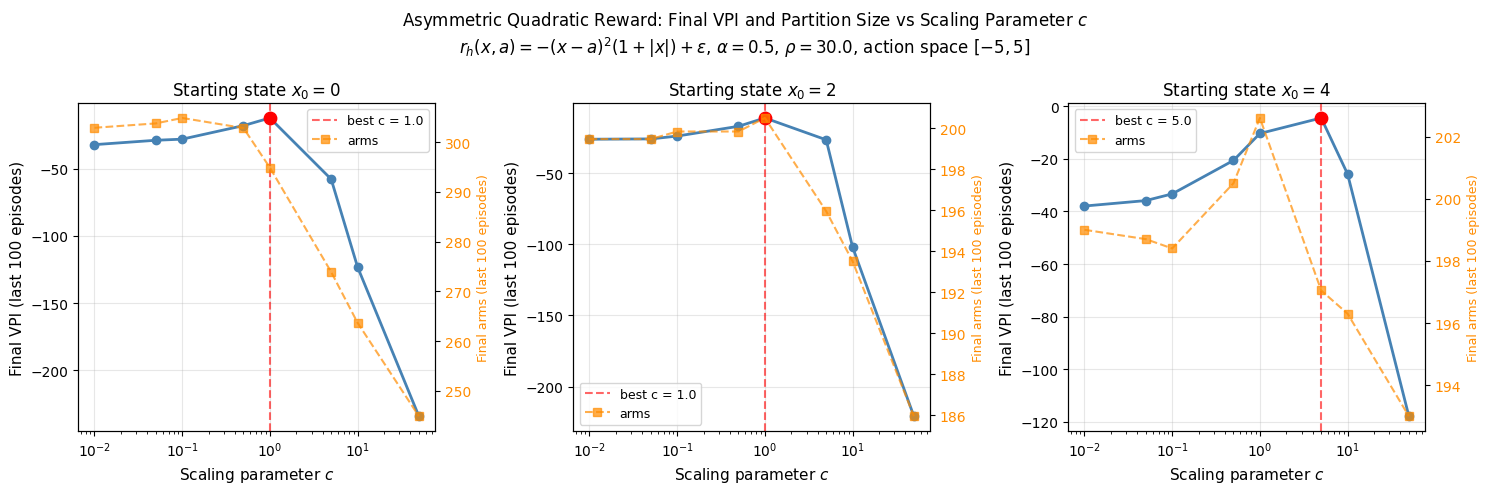

Saved to vpi_vs_c_asymmetric.png


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for idx, s0 in enumerate(starting_states_asym):
    ax = axes[idx]
    
    subset = summary_asym_df[
        summary_asym_df["starting_state"] == s0
    ].sort_values("scaling")
    
    ax.plot(
        subset["scaling"],
        subset["final_vpi_100"],
        marker='o',
        linewidth=2,
        markersize=6,
        color='steelblue'
    )
    
    # mark best c
    best_row = subset.loc[subset["final_vpi_100"].idxmax()]
    ax.axvline(
        x=best_row["scaling"],
        color='red',
        linestyle='--',
        alpha=0.6,
        label=f'best c = {best_row["scaling"]}'
    )
    ax.scatter(
        [best_row["scaling"]],
        [best_row["final_vpi_100"]],
        color='red',
        zorder=5,
        s=80
    )

    # secondary axis for arm count
    ax2 = ax.twinx()
    ax2.plot(
        subset["scaling"],
        subset["final_arms_100"],
        marker='s',
        linewidth=1.5,
        linestyle='--',
        color='darkorange',
        alpha=0.7,
        label='arms'
    )
    ax2.set_ylabel('Final arms (last 100 episodes)', 
                   fontsize=9, color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    ax.set_xscale('log')
    ax.set_xlabel('Scaling parameter $c$', fontsize=11)
    ax.set_ylabel('Final VPI (last 100 episodes)', fontsize=11)
    ax.set_title(f'Starting state $x_0 = {s0}$', fontsize=12)
    ax.grid(True, alpha=0.3)

    # combine legends from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

fig.suptitle(
    'Asymmetric Quadratic Reward: Final VPI and Partition Size vs Scaling Parameter $c$\n'
    r'$r_h(x,a) = -(x-a)^2(1+|x|) + \varepsilon$, '
    f'$\\alpha = {alpha_fixed}$, $\\rho = {rho_val}$, '
    'action space $[-5, 5]$',
    fontsize=12
)

fig.tight_layout()
fig.savefig('vpi_vs_c_asymmetric.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to vpi_vs_c_asymmetric.png')

For large c we see a large decrease in VPI and the arm count appears to follow the trend of the VPI. This confirms that large c supresses splitting, the partition stays coarse and the performace colapses.

As we increase the starting value the optimal value for c increases

For all three panels, performance is relatively flat for small c but collapses rapidly for large c. This is an important asymmetry, being too conservative with splitting is far more costly than being too aggressive. In practical terms this suggests erring on the side of smaller c is safer for this reward structure

For small c starting at 4 behaves poorly, the vpi is much lower than that for starting at 0,2. The below code checks wether we drift outside the optimal action space during the episode.

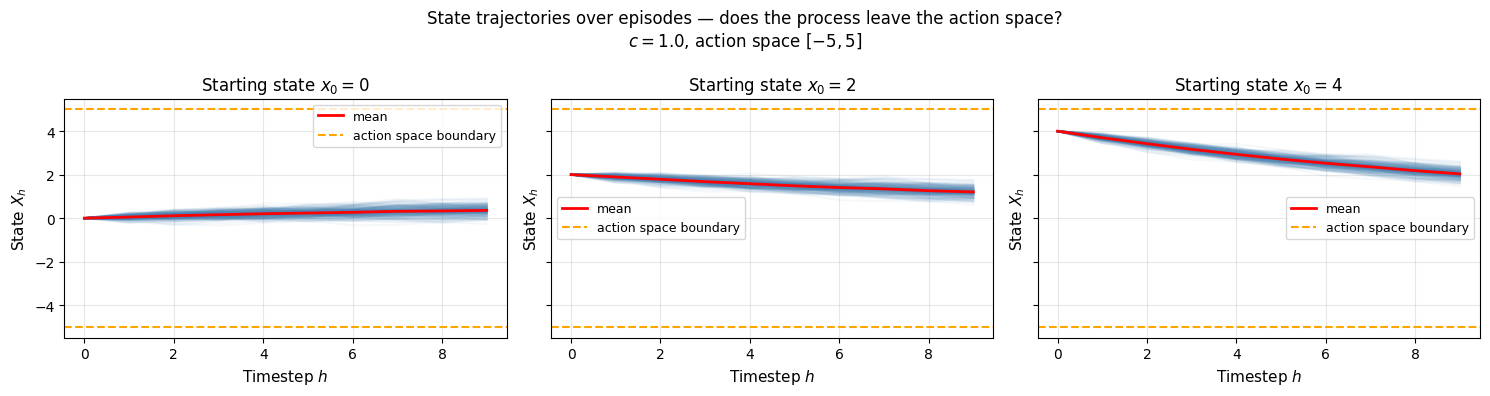

Saved to trajectories_asymmetric.png


In [30]:
def run_one_seed_with_trajectories(seed: int, cfg: c.ExpConfig, n_episodes: int = 100) -> np.ndarray:
    """
    Run experiment and record state trajectories for the first n_episodes.
    Returns array of shape (n_episodes, epLen) containing state values.
    """
    np.random.seed(seed)
    env = c.LinearDiffEnvironment(cfg)
    agent = c.AdaptiveModelBasedDiscretization(cfg)
    trajectories = np.zeros((n_episodes, cfg.epLen))

    for ep in range(n_episodes):
        env.reset()
        state = env.state.copy()
        agent.update_policy(ep)

        for h in range(cfg.epLen):
            action = agent.pick_action(state, h)
            reward, new_state, pContinue = env.advance(action)
            trajectories[ep, h] = state[0]
            agent.update_obs(state, action, reward, new_state, h)
            if not pContinue:
                break
            state[0] = new_state[0]

    return trajectories


# run for each starting state with a fixed mid-range c
traj_results = {}
cfg_fixed_c = 1.0

for s0 in starting_states_asym:
    cfg = c.ExpConfig(
        alpha=alpha_fixed,
        scaling=cfg_fixed_c,
        starting_state=s0,
        rho=rho_val,
        action_lo=-5.0,
        action_hi=5.0,
        initial_q=100.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f"traj|start={s0}"
    )
    # use seed 0 for reproducibility
    traj_results[s0] = run_one_seed_with_trajectories(seed=0, cfg=cfg, n_episodes=200)

# plot state distributions per starting state
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, s0 in enumerate(starting_states_asym):
    ax = axes[idx]
    trajs = traj_results[s0]  # shape (200, 10)

    # plot all trajectories faintly
    for ep in range(trajs.shape[0]):
        ax.plot(range(cfg.epLen), trajs[ep], color='steelblue', alpha=0.05)

    # plot mean trajectory
    ax.plot(range(cfg.epLen), trajs.mean(axis=0),
            color='red', linewidth=2, label='mean')

    # shade action space bounds
    ax.axhline(y=5.0,  color='orange', linestyle='--', 
               linewidth=1.5, label='action space boundary')
    ax.axhline(y=-5.0, color='orange', linestyle='--', linewidth=1.5)

    ax.set_xlabel('Timestep $h$', fontsize=11)
    ax.set_ylabel('State $X_h$', fontsize=11)
    ax.set_title(f'Starting state $x_0 = {s0}$', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'State trajectories over episodes — does the process leave the action space?\n'
    f'$c = {cfg_fixed_c}$, action space $[-5, 5]$',
    fontsize=12
)
fig.tight_layout()
fig.savefig('trajectories_asymmetric.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to trajectories_asymmetric.png')

The above plot shows we dont drift outside the action bounds. These means the worse VPI is not a boundary effect.

**Why does $x_0 = 4$ achieve lower final VPI than $x_0 \in \{0, 2\}$?**

The trajectory plot confirms that the state process stays well within the
action space $[-5, 5]$ for all three starting states — the poorer performance
of $x_0 = 4$ is not caused by boundary clipping.

The explanation lies in the reward structure itself. With
$r_h(x, a) = -(x-a)^2(1+|x|)$, the penalty for any suboptimal action is
scaled by $(1 + |x|)$. The mean-reverting drift $\theta_x = -0.1$ pulls the
state toward zero over the episode, but for $x_0 = 4$ the process spends the
entire episode at moderate to high $|x|$ values — starting near 4 and
finishing near 2. Throughout this trajectory the scaling factor $(1 + |x|)$
is significantly larger than 1, so every suboptimal action incurs a larger
instantaneous penalty than it would for $x_0 \in \{0, 2\}$, where the state
remains close to the origin and the scaling is close to 1.

This is not a failure of the algorithm. It is the reward geometry working
as intended: the asymmetric quadratic is designed so that the cost of
suboptimal actions grows with $|x|$, and a starting state further from zero
naturally accumulates larger penalties over the episode regardless of how
well the algorithm performs.

This shows that the VPI differences across starting states are driven by the reward geometry rather than action space constraints or trajectory pathology. The trajectory plot itself is worth including in your notebook as evidence for this. It rules out the most obvious alternative explanation cleanly

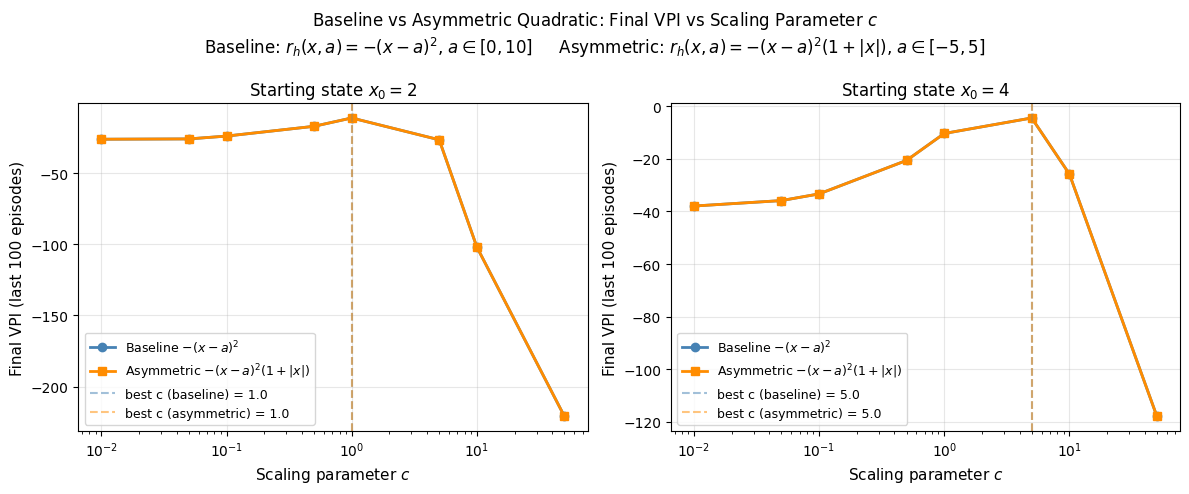

Saved to comparison_baseline_vs_asymmetric.png


In [31]:



fig, axes = plt.subplots(1, 2, figsize=(12, 5))

shared_starts = [2, 4]

for idx, s0 in enumerate(shared_starts):
    ax = axes[idx]

    # --- baseline subset ---
    subset_base = summary_c_df[
        summary_c_df["starting_state"] == s0
    ].sort_values("scaling")

    # --- asymmetric subset ---
    subset_asym = summary_asym_df[
        summary_asym_df["starting_state"] == s0
    ].sort_values("scaling")

    ax.plot(
        subset_base["scaling"],
        subset_base["final_vpi_100"],
        marker='o',
        linewidth=2,
        markersize=6,
        color='steelblue',
        label=r'Baseline $-(x-a)^2$'
    )

    ax.plot(
        subset_asym["scaling"],
        subset_asym["final_vpi_100"],
        marker='s',
        linewidth=2,
        markersize=6,
        color='darkorange',
        label=r'Asymmetric $-(x-a)^2(1+|x|)$'
    )

    # mark best c for each
    best_base = subset_base.loc[subset_base["final_vpi_100"].idxmax()]
    best_asym = subset_asym.loc[subset_asym["final_vpi_100"].idxmax()]

    ax.axvline(
        x=best_base["scaling"],
        color='steelblue',
        linestyle='--',
        alpha=0.5,
        label=f'best c (baseline) = {best_base["scaling"]}'
    )
    ax.axvline(
        x=best_asym["scaling"],
        color='darkorange',
        linestyle='--',
        alpha=0.5,
        label=f'best c (asymmetric) = {best_asym["scaling"]}'
    )

    ax.set_xscale('log')
    ax.set_xlabel('Scaling parameter $c$', fontsize=11)
    ax.set_ylabel('Final VPI (last 100 episodes)', fontsize=11)
    ax.set_title(f'Starting state $x_0 = {s0}$', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Baseline vs Asymmetric Quadratic: Final VPI vs Scaling Parameter $c$\n'
    r'Baseline: $r_h(x,a) = -(x-a)^2$, $a \in [0,10]$     '
    r'Asymmetric: $r_h(x,a) = -(x-a)^2(1+|x|)$, $a \in [-5,5]$',
    fontsize=12
)

fig.tight_layout()
fig.savefig('comparison_baseline_vs_asymmetric.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to comparison_baseline_vs_asymmetric.png')


x0=2 baseline final_vpi_100:
 scaling  final_vpi_100
    0.01     -26.233577
    0.05     -26.017510
    0.10     -24.021644
    0.50     -17.156086
    1.00     -11.299934
    5.00     -26.640120
   10.00    -101.992991
   50.00    -220.829309

x0=2 asymmetric final_vpi_100:
 scaling  final_vpi_100
    0.01     -26.233577
    0.05     -26.017510
    0.10     -24.021644
    0.50     -17.156086
    1.00     -11.299934
    5.00     -26.640120
   10.00    -101.992991
   50.00    -220.829309

x0=4 baseline final_vpi_100:
 scaling  final_vpi_100
    0.01     -37.922614
    0.05     -35.847769
    0.10     -33.301496
    0.50     -20.558437
    1.00     -10.306177
    5.00      -4.397717
   10.00     -25.738421
   50.00    -117.926109

x0=4 asymmetric final_vpi_100:
 scaling  final_vpi_100
    0.01     -37.922614
    0.05     -35.847769
    0.10     -33.301496
    0.50     -20.558437
    1.00     -10.306177
    5.00      -4.397717
   10.00     -25.738421
   50.00    -117.926109


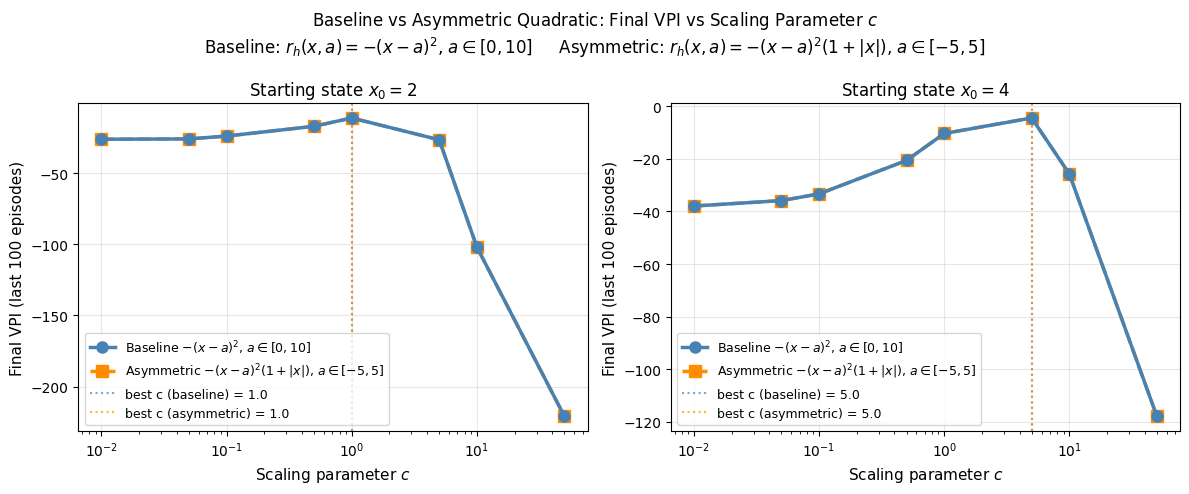

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

shared_starts = [2, 4]

for idx, s0 in enumerate(shared_starts):
    ax = axes[idx]

    subset_base = summary_c_df[
        summary_c_df["starting_state"] == s0
    ].sort_values("scaling")

    subset_asym = summary_asym_df[
        summary_asym_df["starting_state"] == s0
    ].sort_values("scaling")

    # plot baseline first so it sits underneath
    ax.plot(
        subset_base["scaling"],
        subset_base["final_vpi_100"],
        marker='o',
        linewidth=2.5,
        markersize=8,
        color='steelblue',
        zorder=3,
        label=r'Baseline $-(x-a)^2$, $a \in [0,10]$'
    )

    ax.plot(
        subset_asym["scaling"],
        subset_asym["final_vpi_100"],
        marker='s',
        linewidth=2.5,
        markersize=8,
        color='darkorange',
        linestyle='--',
        zorder=2,
        label=r'Asymmetric $-(x-a)^2(1+|x|)$, $a \in [-5,5]$'
    )

    best_base = subset_base.loc[subset_base["final_vpi_100"].idxmax()]
    best_asym = subset_asym.loc[subset_asym["final_vpi_100"].idxmax()]

    ax.axvline(
        x=best_base["scaling"],
        color='steelblue',
        linestyle=':',
        alpha=0.7,
        linewidth=1.5,
        label=f'best c (baseline) = {best_base["scaling"]}'
    )
    ax.axvline(
        x=best_asym["scaling"],
        color='darkorange',
        linestyle=':',
        alpha=0.7,
        linewidth=1.5,
        label=f'best c (asymmetric) = {best_asym["scaling"]}'
    )

    ax.set_xscale('log')
    ax.set_xlabel('Scaling parameter $c$', fontsize=11)
    ax.set_ylabel('Final VPI (last 100 episodes)', fontsize=11)
    ax.set_title(f'Starting state $x_0 = {s0}$', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # print the values so we can see if they genuinely overlap
    print(f"\nx0={s0} baseline final_vpi_100:")
    print(subset_base[["scaling","final_vpi_100"]].to_string(index=False))
    print(f"\nx0={s0} asymmetric final_vpi_100:")
    print(subset_asym[["scaling","final_vpi_100"]].to_string(index=False))

fig.suptitle(
    'Baseline vs Asymmetric Quadratic: Final VPI vs Scaling Parameter $c$\n'
    r'Baseline: $r_h(x,a) = -(x-a)^2$, $a \in [0,10]$     '
    r'Asymmetric: $r_h(x,a) = -(x-a)^2(1+|x|)$, $a \in [-5,5]$',
    fontsize=12
)

fig.tight_layout()
fig.savefig('comparison_baseline_vs_asymmetric.png', dpi=150, bbox_inches='tight')
plt.show()